In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("RFM_Raw.csv")

In [19]:
df.head()

,Date,InvoNo,CustomerKey,Amount
0,2018/01/01,JA1803995,A0620,411.400
1,2018/01/01,JA1805774,A1336,658.240
2,2018/01/01,JA1801197,A0786,1892.352
3,2018/01/02,JA1805224,A0937,411.400
4,2018/01/02,JA1802973,A1371,411.400


In [20]:
import pandas as pd

# 1. 確保Date欄位轉換為 datetime 格式
df["Date"] = pd.to_datetime(df["Date"])

# 2. 計算整個資料集的最大交易日（基準日）
max_date = df["Date"].max()

# 3. 依據CustomerKey進行聚合計算
RFM_Data = (
    df.groupby("CustomerKey")
    .agg(
        # R: 最大交易日 與 該客戶最後交易日 的天數差
        R=("Date", lambda x: (max_date - x.max()).days),
        # F: 交易次數 (計算不重複發票張數，若同一張發票有多列明細也不會重複計算)
        F=("InvoNo", "nunique"),
        # M: 交易總Amount
        M=("Amount", "sum"),
    )
    .reset_index()
)

# 4. 將「CustomerKey」欄位名稱更改為「客戶」
RFM_Data = RFM_Data.rename(columns={"CustomerKey": "客戶"})

# 調整欄位順序（客戶, R, F, M）
RFM_Data = RFM_Data[["客戶", "R", "F", "M"]]

# 檢視成果
print(RFM_Data.head())

      客戶   R   F            M
0  A0350   9  25  51238.11440
1  A0351  16   6  17890.31200
2  A0352  14  14  46424.03852
3  A0353  24  14  27607.68636
4  A0354  31   6   9973.92064


In [21]:
from sklearn.preprocessing import StandardScaler

# 複製原始資料
rfmn = RFM_Data.copy()

# 使用 StandardScaler 進行正規化
scaler = StandardScaler()
rfmn[['R', 'F', 'M']] = scaler.fit_transform(rfmn[['R', 'F', 'M']])

# 檢視正規化後的資料
print(rfmn.head())

      客戶         R         F         M
0  A0350 -0.661105  1.347566  0.710046
1  A0351 -0.536734 -0.753785 -0.566299
2  A0352 -0.572268  0.130994  0.525794
3  A0353 -0.394595  0.130994 -0.194379
4  A0354 -0.270224 -0.753785 -0.869289


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak o

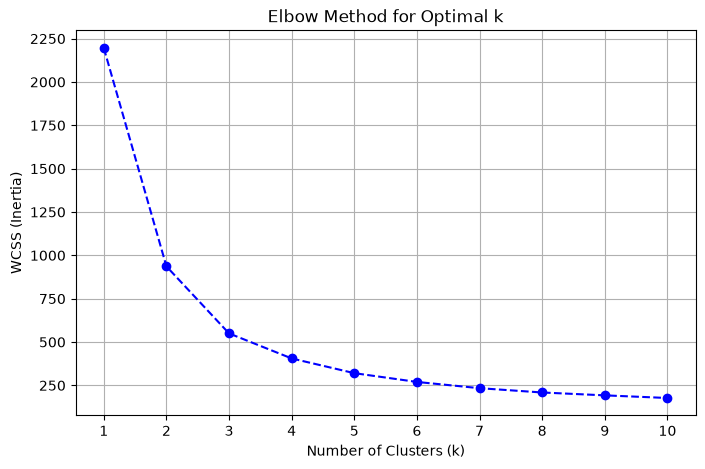

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取 RFM 特徵欄位進行 K-means 計算
X = rfmn[['R', 'F', 'M']]

wcss = []
k_range = range(1, 11)

# 計算不同 k 值下的群內誤差平方和 (Inertia)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 繪製 Elbow Chart
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [23]:
from sklearn.cluster import KMeans

# 提取 RFM 特徵
X = rfmn[['R', 'F', 'M']]

# 執行 k-means 分群 (k = 4)
k=4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfmn['Cluster'] = kmeans.fit_predict(X)

# 顯示各分群的數量分布
print("各分群客戶數量：")
print(rfmn['Cluster'].value_counts())

# 檢視部分結果
print("\n前 5 筆結果：")
print(rfmn.head())

各分群客戶數量：
Cluster
1    315
0    226
2    116
3     75
Name: count, dtype: int64

前 5 筆結果：
      客戶         R         F         M  Cluster
0  A0350 -0.661105  1.347566  0.710046        0
1  A0351 -0.536734 -0.753785 -0.566299        1
2  A0352 -0.572268  0.130994  0.525794        0
3  A0353 -0.394595  0.130994 -0.194379        0
4  A0354 -0.270224 -0.753785 -0.869289        1


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [25]:
rfmn

,客戶,R,F,M,Cluster
0,A0350,-0.661105,1.347566,0.710046,0
1,A0351,-0.536734,-0.753785,-0.566299,1
2,A0352,-0.572268,0.130994,0.525794,0
3,A0353,-0.394595,0.130994,-0.194379,0
4,A0354,-0.270224,-0.753785,-0.869289,1
...,...,...,...,...,...
727,A1413,-0.643338,1.126371,0.767483,0
728,A1415,-0.518966,0.794579,0.778227,0
729,A1416,-0.749942,1.236968,0.660301,0
730,A1419,0.067356,1.015774,1.208360,2


In [26]:
# 載入 Silhouette 套件，為驗證分組成效，需要執行 Silhouette 分析
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(rfmn[["R","F","M"]], rfmn.Cluster)

Text(0.5, 0, 'Item No')

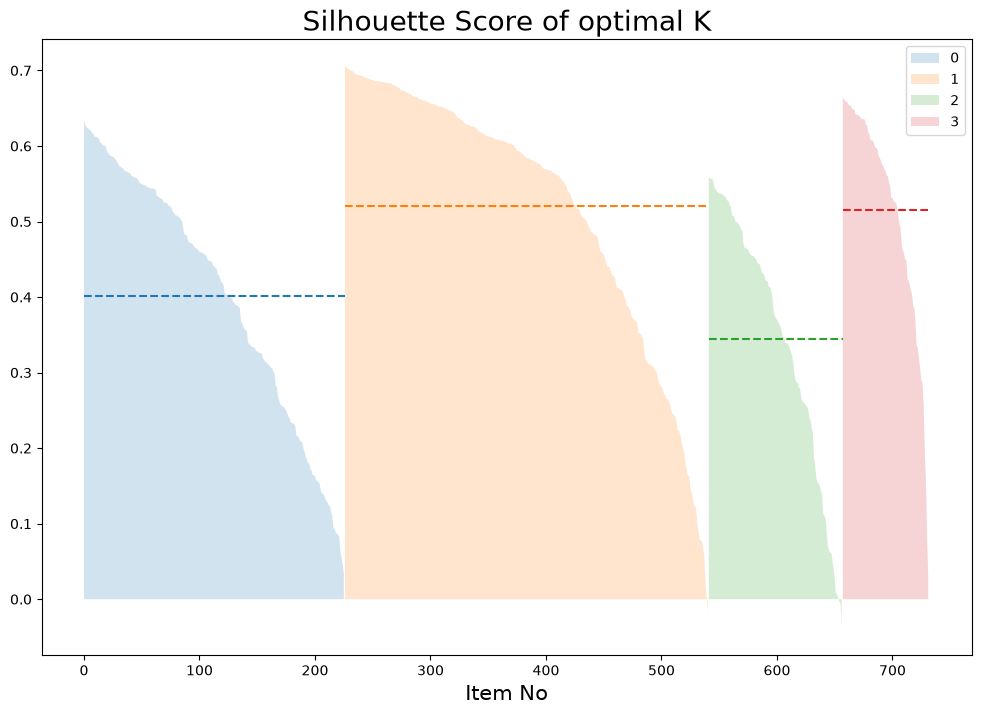

In [27]:
# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

#k=4 #承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):
   
    group_slh=silhouette[rfmn.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿
 
    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線
   
    plt.legend() # 繪製圖例
       
    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)

In [28]:
# 將 rfmn 中的 Cluster 標籤複製回 RFM_Data
RFM_Data['Cluster'] = rfmn['Cluster']

# 檢視合併後的原始 RFM 資料
print(RFM_Data.head())

      客戶   R   F            M  Cluster
0  A0350   9  25  51238.11440        0
1  A0351  16   6  17890.31200        1
2  A0352  14  14  46424.03852        0
3  A0353  24  14  27607.68636        0
4  A0354  31   6   9973.92064        1


In [29]:
#分群的所有標籤
kmeans.labels_

array([0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 3, 1, 0, 1, 0, 0, 1, 2, 3, 2, 3, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 3, 0, 1, 1, 1, 2, 1, 1, 0, 2, 0, 0,
       3, 1, 0, 1, 1, 0, 1, 3, 1, 0, 2, 0, 0, 3, 1, 3, 1, 0, 0, 1, 1, 0,
       2, 1, 1, 0, 3, 1, 1, 1, 0, 0, 0, 3, 2, 0, 2, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 2, 0, 2, 0, 1, 1, 1, 0,
       1, 1, 3, 2, 2, 3, 0, 1, 1, 0, 0, 3, 1, 3, 1, 1, 1, 1, 1, 2, 1, 0,
       0, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 2, 3, 2, 1, 0,
       2, 1, 3, 1, 1, 3, 0, 2, 2, 2, 0, 1, 1, 1, 1, 2, 1, 0, 3, 1, 3, 3,
       0, 0, 0, 2, 1, 1, 0, 3, 1, 0, 1, 3, 2, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       2, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 2, 1, 1, 1, 1, 0, 1, 2, 1, 3,
       0, 0, 1, 1, 3, 3, 2, 1, 3, 3, 0, 1, 3, 1, 2, 2, 0, 0, 1, 0, 0, 1,
       2, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 1, 3, 0, 1, 0, 0, 1, 1, 1, 2, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 2, 0, 2,

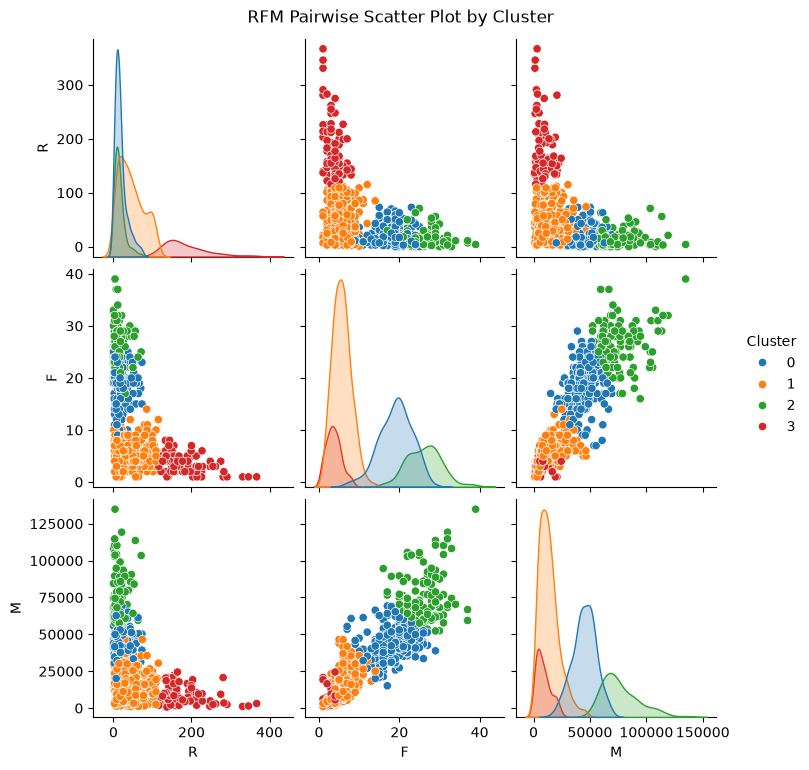

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用 Seaborn 繪製成對散布圖，並依 Cluster 欄位進行著色分群
sns.pairplot(RFM_Data, vars=['R', 'F', 'M'], hue='Cluster', palette='tab10', diag_kind='kde')
plt.suptitle('RFM Pairwise Scatter Plot by Cluster', y=1.02)
plt.show()

In [ ]:
# 定義 Cluster 對應 Group 的對照表
group_mapping = {
    0: 'M',
    1: 'L',
    2: 'H',
    3: 'Missing'
}

# 新增 Group 欄位
RFM_Data['Group'] = RFM_Data['Cluster'].map(group_mapping)

# 檢視更新後的資料與各組別數量
print(RFM_Data['Group'].value_counts())
print("\n資料預覽：")
print(RFM_Data.head())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用 Seaborn 繪製成對散布圖，並依 Group 欄位進行著色分群
g = sns.pairplot(RFM_Data, vars=['R', 'F', 'M'], hue='Group', palette='tab10', diag_kind='kde')
plt.suptitle('RFM Pairwise Scatter Plot by Group', y=1.02)

# 匯出為透明背景的 PNG 格式
g.savefig('RFM_Pair.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 將 RFM_Data 匯出成 CSV 檔案，不保留 index
RFM_Data.to_csv('RFM_Res.csv', index=False)
print("已成功匯出至 RFM_Res.csv")